In [1]:
from _defs._init_update import *
from _defs.iplot import *

defs version: /mnt/data2/_samplecodes/defs/v20260323
defs updated from /mnt/data2/_samplecodes/defs/v20260323.
currentpath:  /mnt/data2/TP_CON/group/PFC/analysis/05_analysis


(10, 1, 5)
[[ 3.8158 20.5436 38.5239 60.0996 70.6886]] [[2.56083497 8.37526375 4.68405507 6.20794536 5.59085704]]
决定系数 (R²): 0.991923
回归显著性 (p值): 0.0003088454
(21, 1, 5)
[[ 3.2497619  23.24190476 44.59671429 74.13842857 85.11557143]] [[ 1.90188635  9.93078481  6.41809663 13.14709614  8.55239038]]
决定系数 (R²): 0.986564
回归显著性 (p值): 0.0006636480
(20, 1, 5)
[[ 3.5967  29.50655 39.89165 59.9179  73.33325]] [[2.35494894 6.30525102 6.56054278 6.12316391 4.74887541]]
决定系数 (R²): 0.983212
回归显著性 (p值): 0.0009278414
0239
0%
              sum_sq    df        F    PR(>F)
group      54.465589   4.0  1.29017  0.288118
Residual  474.928163  45.0      NaN       NaN
4%
8%
15%
100%
2019
0%
               sum_sq     df         F   PR(>F)
group       19.611840    4.0  0.441934  0.77802
Residual  1109.432149  100.0       NaN      NaN
4%
8%
15%
100%
groot
0%
              sum_sq    df         F   PR(>F)
group      69.341216   4.0  1.647048  0.16886
Residual  999.882311  95.0       NaN      NaN
4%
8%
15%
100%


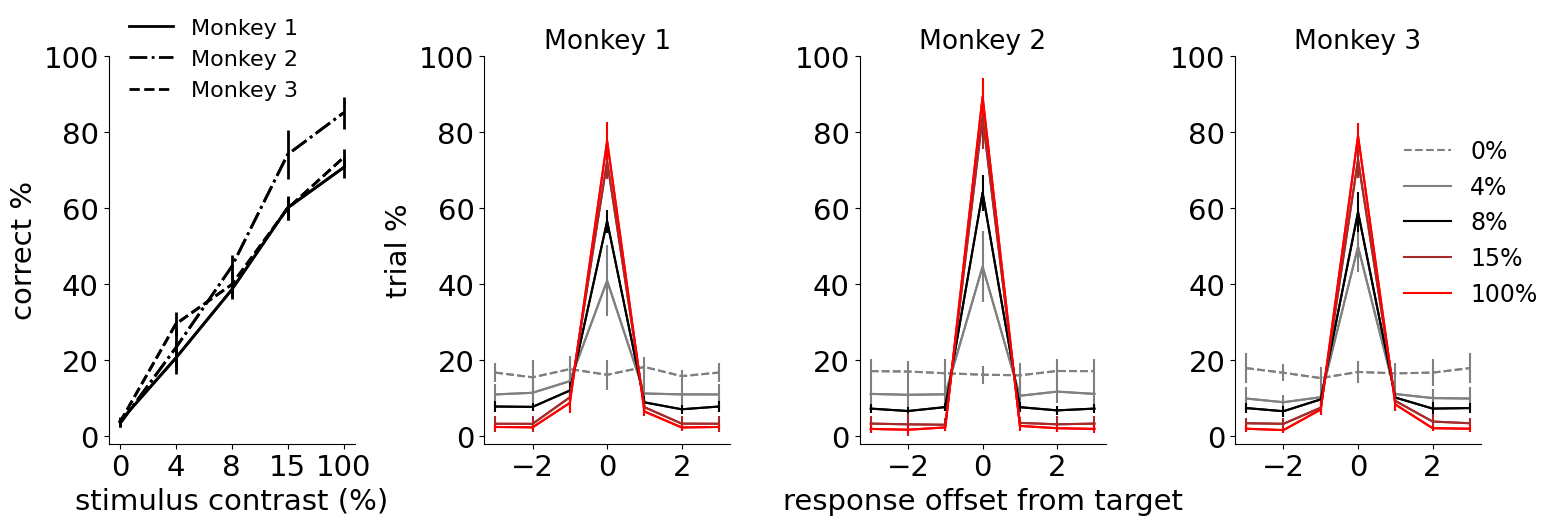

In [30]:
redrat = 3; fs = 7 * redrat

fig = plt.figure(figsize=[5.2 * redrat, 1.8 * redrat])

lss = ['-', '-.', '--']; cs = ['k', 'k', 'k']
ax1 = plt.subplot(1, 4, 1)

for i in range(3):
    behv_sort = load_dictionary_pickle(outputdir + '/behv_m' + str(i+1) + '.pkl')
    data = behv_sort['pfmncs'][:, 4, [[0,1,2,3,6]]]
    a = data.mean(0)
    ae = data.std(0)
    
    print(data.shape)
    print(a, ae)
    
    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(np.arange(1, 6), a)
    r_squared = r_value**2
    print(f"决定系数 (R²): {r_squared:.6f}")
    print(f"回归显著性 (p值): {p_value:.10f}")
    
    x = range(5)
    y = a[0, :]
    yerr = ae[0, :]
    
    ax1.plot(x, y, c=cs[i], lw=2, ls=lss[i], label=behv_sort['animNm'])
    ax1.errorbar(x, y, yerr=yerr/2, ls=lss[i], capsize=0, c=cs[i], lw=2)

ax1.set_ylabel('correct %', fontsize=fs)
ax1.set_ylim([-2, 100])
ax1.set_yticks([0, 20, 40, 60, 80, 100])
ax1.tick_params(axis='y', labelsize=fs)
ax1.tick_params(axis='x', labelsize=fs)

ax1.set_xlabel('stimulus contrast (%)', fontsize=fs)
ax1.set_xticks(x)
ax1.set_xticklabels(['0','4','8','15','100'], fontsize=fs)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)

ax1.legend(frameon=False, loc='upper left', fontsize=fs-5, bbox_to_anchor=(0.0, 1.15))





labels = ['0%','4%','8%','15%','100%']
color2 = ['k','rosybrown','lightcoral','brown','red']
reds = ["gray", "gray", "k", "brown", "red"]
lss2 = ['--', '-', '-', '-', '-']   # renamed to avoid conflict

for i in range(3):
    ax2 = plt.subplot(1, 4, 2+i)
    behv_sort = load_dictionary_pickle(outputdir + '/behv_m' + str(i+1) + '.pkl')
    data = behv_sort['lbs']
    a = data.mean(0)
    ae = data.std(0)
    
    n = len(a[0, 1:])
    print(behv_sort['animID'])
    
    for j in range(n):
        # ANOVA (only print for first animal)
        df = pd.DataFrame(data[:, [2,3,5,6,7], j+1], 
                          columns=data[0, [2,3,5,6,7], 0].astype(str))
        df_long = df.melt(var_name="group", value_name="values")
        model = ols('values ~ group', data=df_long).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        print(labels[j])
        if j==0: print(anova_table)
        
        ax2.plot(a[1:, 0], a[1:, j+1], c=reds[j], linestyle=lss2[j], lw=1.5)
        ax2.errorbar(a[1:, 0], a[1:, j+1], yerr=ae[1:, j+1], 
                     linestyle=lss2[j], capsize=0, c=reds[j], lw=1.5)

    ax2.set_ylim([-2, 100])
    ax2.set_yticks([0, 20, 40, 60, 80,100])
    ax2.tick_params(axis='both', labelsize=fs)
    
   
   
    ax2.set_xticks([-2, 0, 2])
    ax2.tick_params(axis='x', labelsize=fs)
    ax2.set_title(behv_sort['animNm'],fontsize=fs-2)
    
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(True)
    ax2.spines['left'].set_visible(True)
    if i==2: ax2.legend(labels,frameon=False,fontsize=fs-4,bbox_to_anchor=(0.6, 0.3))
    if i==1: ax2.set_xlabel('response offset from target', fontsize=fs)
    if i==0: ax2.set_ylabel('trial %', fontsize=fs)


plt.tight_layout()
plt.show()

fig.savefig(outputdir+'/_figs/'+'fig1cd.pdf', format='pdf', dpi=300, bbox_inches='tight')

(10, 1, 5)
[[ 3.8158 20.5436 38.5239 60.0996 70.6886]] [[2.56083497 8.37526375 4.68405507 6.20794536 5.59085704]]
决定系数 (R²): 0.991923
回归显著性 (p值): 0.0003088454
(21, 1, 5)
[[ 3.2497619  23.24190476 44.59671429 74.13842857 85.11557143]] [[ 1.90188635  9.93078481  6.41809663 13.14709614  8.55239038]]
决定系数 (R²): 0.986564
回归显著性 (p值): 0.0006636480
(20, 1, 5)
[[ 3.5967  29.50655 39.89165 59.9179  73.33325]] [[2.35494894 6.30525102 6.56054278 6.12316391 4.74887541]]
决定系数 (R²): 0.983212
回归显著性 (p值): 0.0009278414
0239
0%
              sum_sq    df        F    PR(>F)
group      54.465589   4.0  1.29017  0.288118
Residual  474.928163  45.0      NaN       NaN
4%
8%
15%
100%
2019
0%
               sum_sq     df         F   PR(>F)
group       19.611840    4.0  0.441934  0.77802
Residual  1109.432149  100.0       NaN      NaN
4%
8%
15%
100%
groot
0%
              sum_sq    df         F   PR(>F)
group      69.341216   4.0  1.647048  0.16886
Residual  999.882311  95.0       NaN      NaN
4%
8%
15%
100%


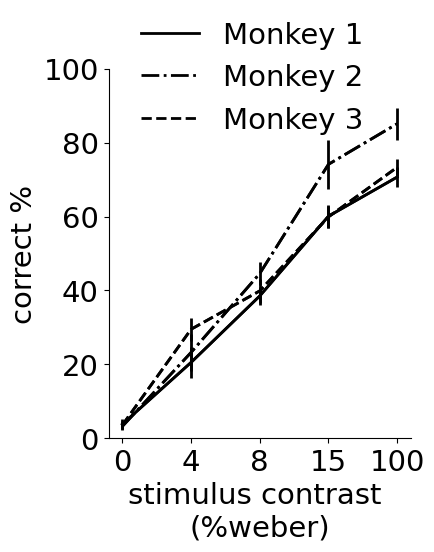

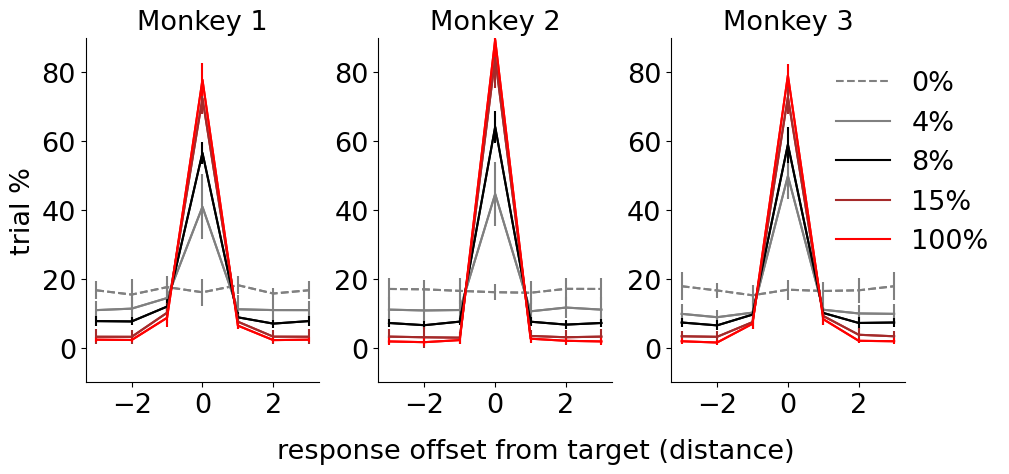

In [3]:

lss=['-','-.','--']
cs = ['k','k','k']

redrat = 3; fs=7*redrat
fig=plt.figure(figsize=[1.3*redrat,1.6*redrat])

for i in range(3):
    behv_sort = load_dictionary_pickle(outputdir+'/behv_m'+str(i+1)+'.pkl')
    data = behv_sort['pfmncs'][:,4,[[0,1,2,3,6]]]
    a = data.mean(0); ae = data.std(0); 
    print(data.shape);print(a,ae)
    slope, intercept, r_value, p_value, std_err = stats.linregress(np.arange(1, 6), a)
    r_squared = r_value**2
    print(f"决定系数 (R²): {r_squared:.6f}");print(f"回归显著性 (p值): {p_value:.10f}")
    
    x = range(5);y=a[0,:];yerr=ae[0,:]
    plt.plot(x,y,c=cs[i],lw=2,ls=lss[i],label=behv_sort['animNm'])
    plt.errorbar(x, y, yerr=yerr/2, ls=lss[i], capsize=0,c=cs[i],lw=2)
    plt.ylabel('correct %',fontsize=fs);plt.ylim([0,100]);plt.yticks(fontsize=fs)
    plt.xlabel('stimulus contrast \n(%weber)',fontsize=fs)
    plt.xticks(x,labels=['0','4','8','15','100'],fontsize=fs)
    
    plt.gca().spines['top'].set_visible(False);plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(True);plt.gca().spines['left'].set_visible(True)
plt.legend(frameon=False,loc='upper left',fontsize=fs,bbox_to_anchor=(0.02, 1.2));

# fig.savefig(outputdir+'/_figs/'+'fig1c.pdf', format='pdf', dpi=300, bbox_inches='tight')



labels = ['0%','4%','8%','15%','100%']
color2 = ['k','rosybrown','lightcoral','brown','red']
reds = [ "gray", "gray", "k", "brown", "red"]
lss = ['--','-','-','-','-']


redrat = 3; fs=6.5*redrat
fig=plt.figure(figsize=[3.4*redrat,1.6*redrat])
plt.suptitle('response offset from target (distance)',x=0.53,y=-0.01,fontsize=fs)

for i in range(3):
    behv_sort = load_dictionary_pickle(outputdir+'/behv_m'+str(i+1)+'.pkl')
    data = behv_sort['lbs']
    a = data.mean(0); ae = data.std(0);
    
    n=len(a[0,1:])
    print(behv_sort['animID'])
    plt.subplot(1,3,i+1)
    for j in range(n):
        df = pd.DataFrame(data[:,[2,3,5,6,7],j+1], columns=data[0,[2,3,5,6,7],0].astype(str))
        # Reshape the DataFrame to long format
        df_long = df.melt(var_name="group", value_name="values")
        
        # Perform the one-way ANOVA
        model = ols('values ~ group', data=df_long).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        print(labels[j])
        if j==0: print(anova_table)
    
        plt.plot(a[1:,0], a[1:,j+1],c=reds[j], linestyle=lss[j],lw=1.5)
        plt.errorbar(a[1:,0], a[1:,j+1], yerr=ae[1:,j+1], linestyle=lss[j], capsize=0,c=reds[j],lw=1.5)
    if i==2: plt.legend(labels,frameon=False,fontsize=fs,bbox_to_anchor=(0.6, 0.3))

    if i==0: plt.ylabel('trial %',fontsize=fs);

    plt.ylim([-10,90]);plt.yticks([0,20,40,60,80],fontsize=fs)
    plt.title(behv_sort['animNm'],fontsize=fs)
    plt.xticks([-2,0,2],fontsize=fs)
    plt.gca().spines['top'].set_visible(False);plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(True);plt.gca().spines['left'].set_visible(True)
plt.tight_layout()
# fig.savefig(outputdir+'/_figs/'+'fig1d.pdf', format='pdf', dpi=300, bbox_inches='tight')






Target 1
0239
(10, 5)
[17.02929827 39.33149282 53.27151379 68.37374584 75.8918787 ] [ 4.60609619 12.56293409  3.40123395  6.83809852  5.55352479]
决定系数 (R²): 0.971819
回归显著性 (p值): 0.0020250838
2019
(21, 5)
[16.49918877 49.02328388 69.65952553 87.87394963 92.62997158] [3.55128821 8.42171297 5.71958457 6.14280815 3.76508763]
决定系数 (R²): 0.936852
回归显著性 (p值): 0.0068670256
groot
(20, 5)
[16.861344   57.91172327 64.22113677 77.98885631 82.60880967] [3.72042556 9.13026913 7.09897371 6.14684844 4.03682209]
决定系数 (R²): 0.845305
回归显著性 (p值): 0.0271317291
Target 2
0239
(10, 5)
[15.27501383 42.52338475 59.85587656 76.38392752 79.57988057] [5.15164716 9.8056196  5.17422296 4.69770706 5.10788065]
决定系数 (R²): 0.936587
回归显著性 (p值): 0.0069107859
2019
(21, 5)
[15.83824986 40.26667804 58.57698638 80.16130737 86.09607918] [ 4.66039758 11.8878015   4.55683763 11.56371571  6.45307859]
决定系数 (R²): 0.969694
回归显著性 (p值): 0.0022598759
groot
(20, 5)
[16.93640133 41.77536632 53.7241235  67.54595262 75.46865482] [4.0127962

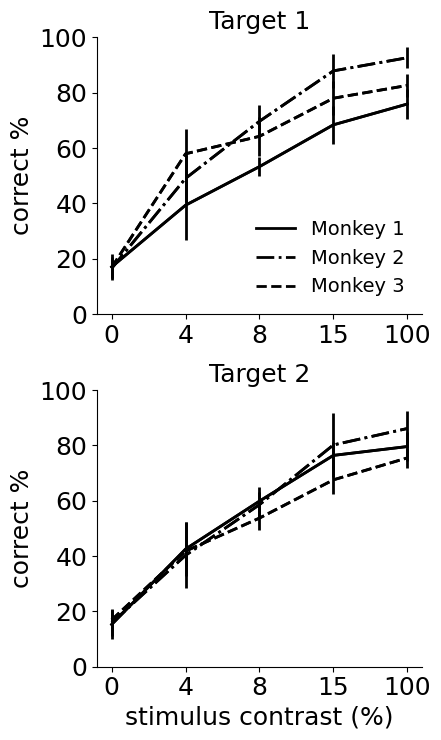

In [55]:
lss=['-','-.','--']
cs = ['k','k','k']


redrat = 3; fs=6*redrat
fig=plt.figure(figsize=[1.5*redrat,2.5*redrat])
for rid in range(2):
    print('Target '+str(rid+1))
    plt.subplot(2,1,rid+1)
    for i in range(3):
        behv_sort = load_dictionary_pickle(outputdir+'/behv_m'+str(i+1)+'.pkl')
        print(behv_sort['animID'])
        if rid ==0: 
            data = behv_sort['pfmncs3_1'][:,3,:]
        elif rid == 1:
            data = behv_sort['pfmncs3_2'][:,3,:]
        a = data.mean(0); ae = data.std(0);
        print(data.shape); print(a,ae)
        slope, intercept, r_value, p_value, std_err = stats.linregress(np.arange(1, 6), a)
        r_squared = r_value**2
        print(f"决定系数 (R²): {r_squared:.6f}");print(f"回归显著性 (p值): {p_value:.10f}")
        x = range(5);y=a;yerr=ae
        plt.plot(x,y,c=cs[i],lw=2,ls=lss[i],label=behv_sort['animNm'])
        plt.errorbar(x, y, yerr=yerr, ls=lss[i], capsize=0,c=cs[i],lw=2)
        plt.ylabel('correct %',fontsize=fs);plt.ylim([0,100]);plt.yticks(fontsize=fs)
        
    if rid==0: plt.legend(frameon=False,loc='lower right',fontsize=fs-4)
    if rid==1: plt.xlabel('stimulus contrast (%)',fontsize=fs)
    plt.xticks(x,labels=['0','4','8','15','100'],fontsize=fs)
    plt.gca().spines['top'].set_visible(False);plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(True);plt.gca().spines['left'].set_visible(True)
    plt.title('Target '+str(rid+1),fontsize=fs)

plt.tight_layout()

fig.savefig(outputdir+'/_figs/'+'figs1b.pdf', format='pdf', dpi=300, bbox_inches='tight')

0239
2019
groot


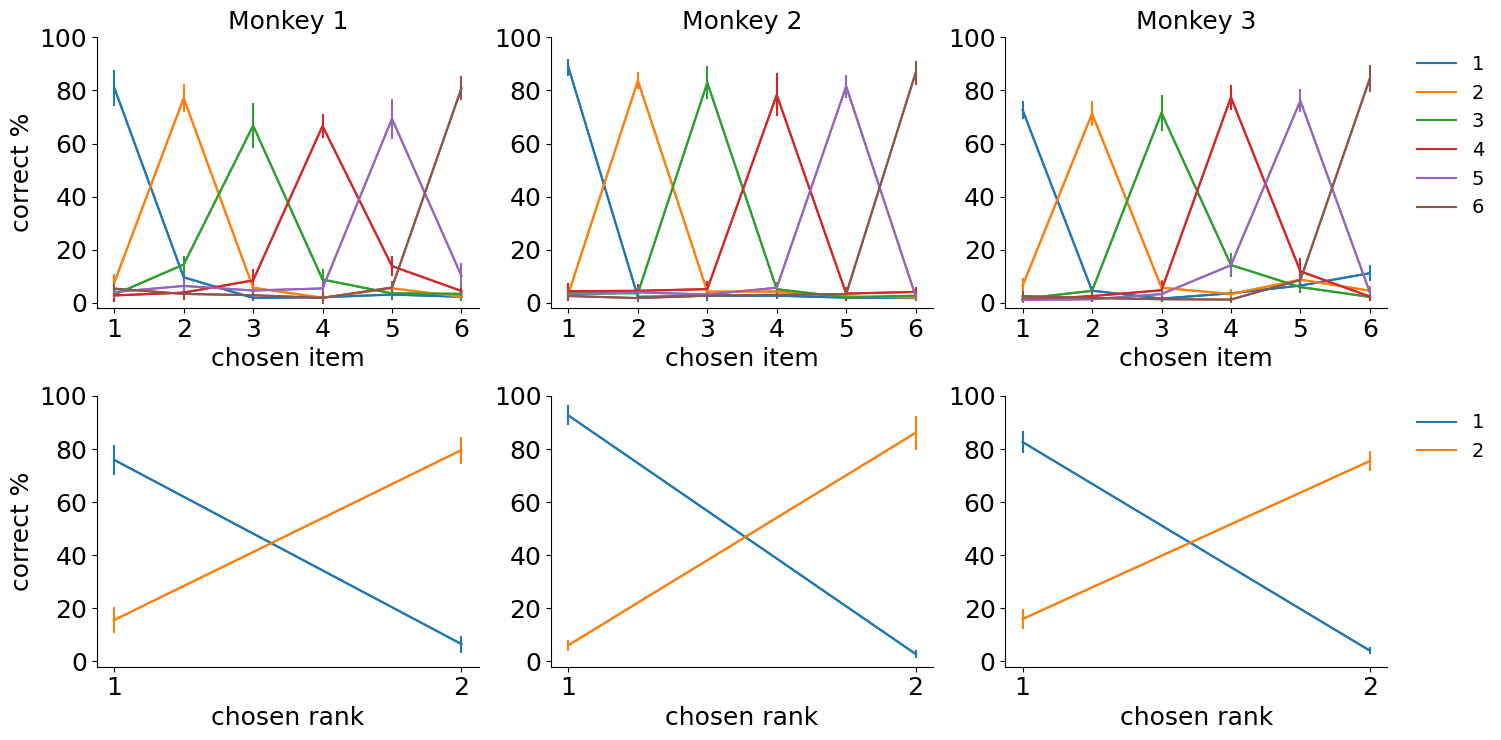

In [54]:
redrat = 3; fs=6*redrat
fig=plt.figure(figsize=[5*redrat,2.5*redrat])
for i in range(3):
    behv_sort = load_dictionary_pickle(outputdir+'/behv_m'+str(i+1)+'.pkl')
    print(behv_sort['animID'])

    plt.subplot(2,3,1+i)
    citems = behv_sort['citems']*100
    a = citems.mean(0); ae = citems.std(0);
    x = np.arange(1,7)
    for j in range(len(x)):
        plt.plot(x,a[j+1,:],c=colors[j])
        plt.errorbar(x, a[j+1,:], yerr=ae[j+1,:], linestyle='-', capsize=0,c=colors[j])

    if i==2: plt.legend(x,bbox_to_anchor=(0.5, 0, 0.8, 1.),frameon=False,fontsize=fs-4)
        
    if i==0: plt.ylabel('correct %',fontsize=fs);
    plt.ylim([-2,100]);plt.yticks(fontsize=fs);plt.xticks(x,fontsize=fs);
    plt.xlabel('chosen item',fontsize=fs);plt.title(behv_sort['animNm'],fontsize=fs)
    
    plt.gca().spines['top'].set_visible(False);plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(True);plt.gca().spines['left'].set_visible(True)

    plt.subplot(2,3,4+i)
    cranks = behv_sort['cranks']*100
    a = cranks.mean(0); ae = cranks.std(0);
    x = np.arange(1,3)
    for j in range(len(x)):
        plt.plot(x,a[j+1,:],c=colors[j])
        plt.errorbar(x, a[j+1,:], yerr=ae[j+1,:], linestyle='-', capsize=0,c=colors[j])


    if i==2: plt.legend(x,bbox_to_anchor=(0.5, 0, 0.8, 1.),frameon=False,fontsize=fs-4)
    if i==0: plt.ylabel('correct %',fontsize=fs);
    plt.ylim([-2,100]);plt.yticks(fontsize=fs)
    plt.xlabel('chosen rank',fontsize=fs);plt.xticks(x,fontsize=fs);

    plt.gca().spines['top'].set_visible(False);plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(True);plt.gca().spines['left'].set_visible(True)

plt.tight_layout()
fig.savefig(outputdir+'/_figs/'+'figs1a.pdf', format='pdf', dpi=300, bbox_inches='tight')

0239
[16.39100129 18.12164612 15.81767598  7.58725552 21.33486743 20.74755367]
2019
[11.56156547 16.4129711  22.7734273  18.32294416 20.20159318 10.7274988 ]
groot
[11.09914474 11.65033139 13.86589923 25.98748832 26.69730819 10.69982813]


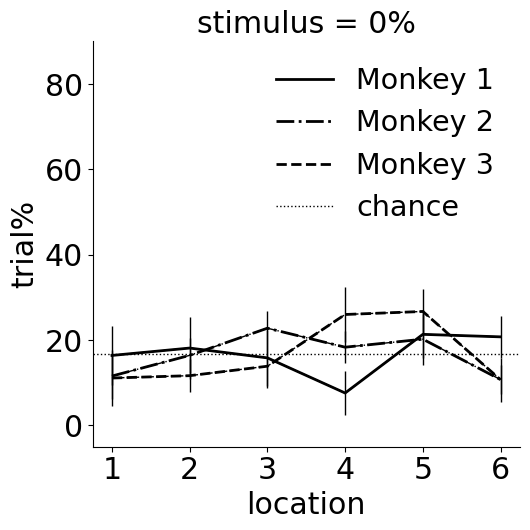

In [66]:
lss=['-','-.','--',':'];

redrat=3.6;fs=6*redrat
fig=plt.figure(figsize=[1.5*redrat,1.5*redrat]);
for i in range(3):
    behv_sort = load_dictionary_pickle(outputdir+'/behv_m'+str(i+1)+'.pkl')
    print(behv_sort['animID'])
    data = behv_sort['citems3']*100
    a = data.mean(0); n=data.shape[0]; ae = data.std(0); 
    print(a[2,:])
    
    x = [1,2,3,4,5,6]
    plt.plot(x,a[2,:],c='k',linestyle=lss[i],label= behv_sort['animNm'],lw=2)
    plt.errorbar(x, a[2,:], yerr=ae[2,:], 
                 linestyle=lss[i], capsize=0,c='k',lw=1)
plt.axhline(100/6,ls=':',lw=1,c='k',label='chance')
plt.legend(frameon=False,fontsize=fs-1)
plt.ylabel('trial%',fontsize=fs);
plt.xlabel('location',fontsize=fs);
plt.ylim([-5,90]);plt.yticks([0,20,40,60,80],fontsize=fs)
plt.xticks(x,fontsize=fs)
plt.title('stimulus = 0%',fontsize=fs)
plt.gca().spines['top'].set_visible(False);plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(True);plt.gca().spines['left'].set_visible(True)

plt.tight_layout()
fig.savefig(outputdir+'/_figs/'+'fig3a.pdf', format='pdf', dpi=300, bbox_inches='tight')

0239: 0.0712963260512133
2019: 0.039473720135662645
groot: 0.052543347623751166


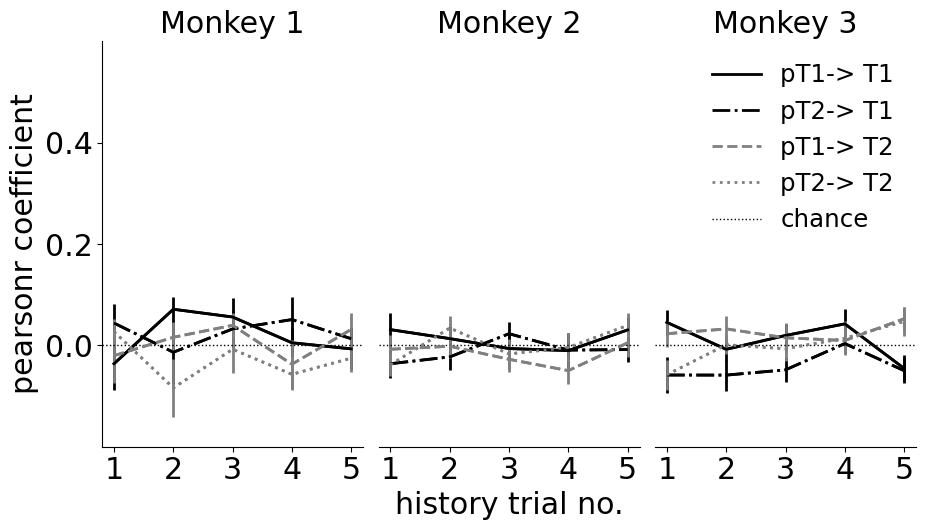

In [67]:
lss=['-','-.','--',':']; color2 = ['k','k','gray','gray','red']

redrat=3.6;fs=6*redrat
fig=plt.figure(figsize=[2.6*redrat,1.5*redrat])

for i in range(3):
    plt.subplot(1,3,i+1)
    behv_sort = load_dictionary_pickle(outputdir+'/behv_m'+str(i+1)+'.pkl')
    print(behv_sort['animID'],end=': ')
    sdps = behv_sort['sdps3'][:,:,:5]
    
    x=[];xlabels=[]
    for ii in range(sdps.shape[2]):
        x.append(ii+1)
        xlabels.append(str(ii+1))
    print(sdps.mean(0).max(0).max())
    
    for ii in range(sdps.shape[1]):
        plt.plot(x,sdps[:,ii,:].mean(0),label='pT'+str(ii%2+1)+'-> T'+str(ii//2+1),c=color2[ii],ls=lss[ii],lw=2)
        plt.errorbar(x,sdps[:,ii,:].mean(0),yerr=sdps[:,ii,:].std(0)/np.sqrt(sdps[:,ii,:].shape[0]),
                     c=color2[ii],ls=lss[ii],lw=2)
    plt.axhline(0,ls=':',c='k',lw=1,label='chance')
    plt.title(behv_sort['animNm'],fontsize=fs)
    plt.ylim([-0.2,0.6]);
    plt.yticks([0,0.2,0.4],fontsize=fs)
    plt.xticks(x,labels=xlabels,fontsize=fs);
    if i!=0: plt.yticks([])
    if i ==0: plt.ylabel('pearsonr coefficient',fontsize=fs);
    if i==1: plt.xlabel('history trial no.',fontsize=fs);
    if i ==2: plt.legend(frameon=False,fontsize=fs-4)
    plt.gca().spines['top'].set_visible(False);plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(True);
    if i==0: plt.gca().spines['left'].set_visible(True) 
    else: plt.gca().spines['left'].set_visible(False)


plt.tight_layout()
fig.savefig(outputdir+'/_figs/'+'fig3b.pdf', format='pdf', dpi=300, bbox_inches='tight')